In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
string_db_file = "/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/protein-abundance-PMDA2025/data/raw/9606.protein.links.detailed.v12.0.txt.gz"
db = pd.read_csv(
    string_db_file,
    compression="gzip",
    sep=" ",
    usecols=["protein1", "protein2", "coexpression", "experimental", "combined_score"]
)

In [20]:
# normalize coexpression column
db["coexpression"] = (db["coexpression"] - db["coexpression"].min()) / (db["coexpression"].max() - db["coexpression"].min())
db["experimental"] = (db["experimental"] - db["experimental"].min()) / (db["experimental"].max() - db["experimental"].min())

In [ ]:
matrix = db.pivot(index="protein1", columns="protein2", values="coexpression").fillna(0)

In [5]:
# check sparsity of the matrix
sparsity = 1 - (matrix != 0).mean().mean()

In [6]:
import umap

umap_model = umap.UMAP(
    metric="cosine",
    random_state=42,
    n_neighbors=15,
    min_dist=0.1,
    n_components=3
)

/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/conda-envs/pmda-valentyn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
tranformed = umap_model.fit_transform(matrix)

/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/conda-envs/pmda-valentyn/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [12]:
umap_df = pd.DataFrame(
    tranformed,
    columns=[
        "coexpression_umap_x",
        "coexpression_umap_y",
        "coexpression_umap_z"],
    index=matrix.index
)

Text(0.5, 1.0, 'UMAP projection of STRING coexpression network')

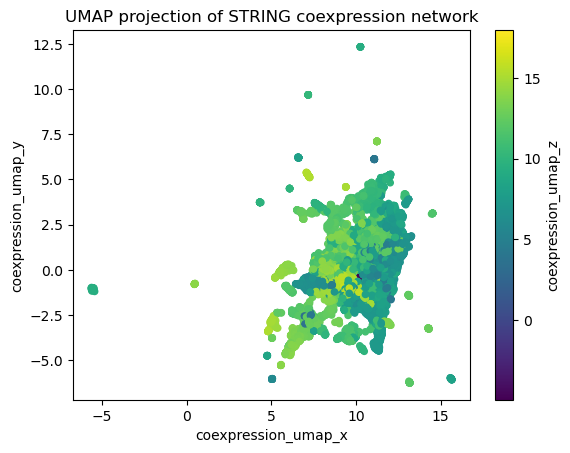

In [14]:
umap_df.plot.scatter(x="coexpression_umap_x", y="coexpression_umap_y", c= "coexpression_umap_z",
    colormap="viridis")
# add title
plt.title("UMAP projection of STRING coexpression network")

In [27]:
umap_df.to_csv("/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/protein-abundance-PMDA2025/data/raw/processed/umap_string_coexpression.tsv.gz",
               sep="\t", compression="gzip")

<Axes: xlabel='experimental_umap_x', ylabel='experimental_umap_y'>

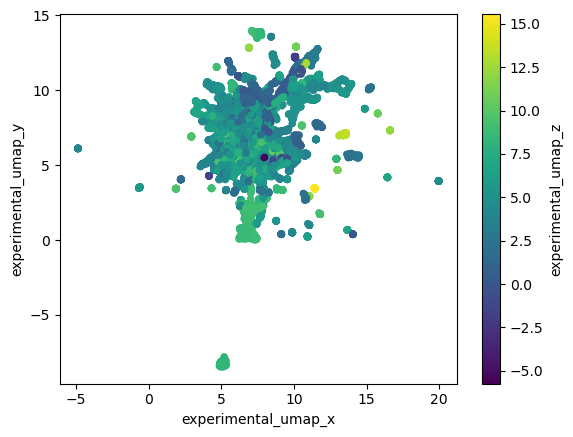

In [28]:
experimental_pivot = db.pivot(index="protein1", columns="protein2", values="experimental").fillna(0)
experimental_umap = umap_model.fit_transform(experimental_pivot)

experimental_umap_df = pd.DataFrame(
    experimental_umap,
    columns=[
        "experimental_umap_x",
        "experimental_umap_y",
        "experimental_umap_z"]
)


# plot experimental UMAP
experimental_umap_df.plot.scatter(x="experimental_umap_x", y="experimental_umap_y", c= "experimental_umap_z",
    colormap="viridis")

In [29]:
# save
experimental_umap_df.to_csv("/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/protein-abundance-PMDA2025/data/raw/processed/umap_string_experimental.tsv.gz",
                sep="\t", compression="gzip")

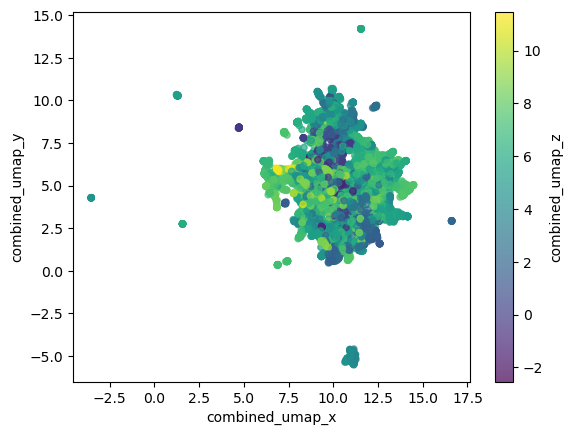

In [32]:
combined_matrix = db.pivot(index="protein1", columns="protein2", values="combined_score").fillna(0)

combined_umap = umap_model.fit_transform(combined_matrix)

combined_umap_df = pd.DataFrame(
    combined_umap,
    columns=[
        "combined_umap_x",
        "combined_umap_y",
        "combined_umap_z"],
    index=combined_matrix.index
)

combined_umap_df.plot.scatter(x="combined_umap_x", y="combined_umap_y", c= "combined_umap_z",
                               colormap="viridis", alpha=0.7)

combined_umap_df.to_csv("/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/protein-abundance-PMDA2025/data/raw/processed/umap_string_combined.tsv.gz",
                        sep="\t", compression="gzip")